In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.sparse import vstack
from pathlib import Path
from sklearn.model_selection import cross_val_score
import joblib

import lightgbm as lgb

def lemmatize(text,model):
    doc = model(text)
    lemmatized = " ".join([token.lemma_ for token in doc])
    return lemmatized

def nlp_predict(data,model,tfidf_vectorizer,col_input = 'portuguese_lemma', inplace = True):
    import pandas as pd
    # vocab03 = tfidf_vectorizer.vocabulary_

    if isinstance(data, pd.Series):
        data_in = data.copy()
    elif isinstance(data, pd.DataFrame):
        data_in = data[col_input]
        
    data_tfidf = tfidf_vectorizer.transform(data_in)
    prediction = model.predict(data_tfidf)
    
    # vocab04 = tfidf_vectorizer.vocabulary_
    if isinstance(data, pd.Series):
        out_df = pd.DataFrame({'sentence':data, 'prediction':prediction})
        return out_df
    
    elif isinstance(data, pd.DataFrame):
        if inplace:
            data['prediction'] = prediction
            return data
        else:
            out_data = data.copy()
            out_data['prediction'] = prediction
            return out_data
    
    
    return out_df


def nlp_predict_prob(data,model,tfidf_vectorizer,col_input = 'portuguese_lemma', inplace = True):
    # !!! TOFIX when inplace = True, it still doesn't change the original df
    # doesn't seem to be useful if the prob predict is very low and I want to flag it as not sure
    
    import pandas as pd
    # vocab03 = tfidf_vectorizer.vocabulary_

    if isinstance(data, pd.Series):
        data_in = data.copy()
    elif isinstance(data, pd.DataFrame):
        data_in = data[col_input]
        
    data_tfidf = tfidf_vectorizer.transform(data_in)
    prediction = model.predict_proba(data_tfidf)
    
    labels = model.classes_.tolist()
    
    prob_df = pd.DataFrame(prediction, columns=[label + '_prob' for label in labels]).set_index(data.index)
    out_df = nlp_predict(data, model, tfidf_vectorizer,col_input,inplace)
    
    # vocab04 = tfidf_vectorizer.vocabulary_
    if isinstance(data, pd.Series):
        data = pd.concat([out_df,prob_df], axis = 1)
        return out_df
    
    elif isinstance(data, pd.DataFrame):
        if inplace:
            data = pd.concat([out_df,prob_df ], axis = 1)
            return data
        else:
            out_data = pd.concat([out_df,prob_df ], axis = 1)
            return out_data



def ml_upsampling(X_df, y_df, verbose = 1):
    
    import pandas as pd
    import numpy as np
    
    """
    Perform manual upsampling on a dataset to balance class distribution.

    This function upsamples the minority classes in a dataset to match the 
    number of instances in the majority class. It operates by randomly 
    duplicating instances of the minority classes.

    Parameters:
    X_df (pd.DataFrame): DataFrame containing the feature set.
    y_df (pd.Series): Series containing the target variable with class labels.
    verbose: 
        0 print nothing
        1 print out before & after upsampling
    

    Returns:
    list: Contains two elements:
        - pd.DataFrame: The upsampled feature DataFrame.
        - pd.Series: The upsampled target Series.

    Note:
    The function does not modify the input DataFrames directly. Instead, it 
    returns new DataFrames with the upsampled data. The indices of the 
    returned DataFrames are reset to maintain uniqueness.
    """
    
    
    # Determine the majority class and its count
    majority_class = y_df.value_counts().idxmax()
    majority_count = y_df.value_counts().max()
    
    if verbose == 0:
        pass
    elif verbose == 1:
        print("Before upsampling: ")
        print()
        print(y_df.value_counts())
        print()
    
    
    # Initialize the upsampled DataFrames
    X_train_oversampled = X_df.copy()
    y_train_oversampled = y_df.copy()

    # Perform manual oversampling for minority classes
    for label in y_df.unique():
        if label != majority_class:
            samples_to_add = majority_count - y_df.value_counts()[label]
            indices = y_df[y_df == label].index
            random_indices = np.random.choice(indices, samples_to_add, replace=True)
            X_train_oversampled = pd.concat([X_train_oversampled, X_df.loc[random_indices]], axis=0)
            y_train_oversampled = pd.concat([y_train_oversampled, y_df.loc[random_indices]])

    # Reset index to avoid duplicate indices
    X_train_oversampled.reset_index(drop=True, inplace=True)
    y_train_oversampled.reset_index(drop=True, inplace=True)
    
    if verbose == 0:
        pass
    elif verbose == 1:
        print("After upsampling: ")
        print()
        print(y_train_oversampled.value_counts())
        print()
    
    return [X_train_oversampled, y_train_oversampled]


def nlp_make_tfidf_matrix(X,text_col, ngram_range =(1,1),stop_words = [], max_df = 0.7):
    import pandas as pd
    from sklearn.feature_extraction.text import TfidfVectorizer
    
    if isinstance(X,pd.Series):
        X_in = X.copy()
    elif isinstance(X,pd.DataFrame):
        X_in = X[text_col]
    else:
        raise TypeError("X should only pd.Series or pd.DataFrame as of now")
    
    tfidf_vectorizer = TfidfVectorizer(stop_words=stop_words,ngram_range=ngram_range,max_df=max_df)
    X_tfidf = tfidf_vectorizer.fit_transform(X_in)
    X_out_df = pd.DataFrame(X_tfidf.toarray(), columns=tfidf_vectorizer.get_feature_names_out(), index=X.index)
    
    return [X_out_df,tfidf_vectorizer]

def os_add_extension(ori_path, added_extension, inplace = True):
    # still doesn't work
    # still can't modify the text direclty
    # imported from "C:\Users\Heng2020\OneDrive\Python NLP\NLP 05_UsefulSenLabel\sen_useful_GPT01.py"
    ori_path_in = [ori_path] if isinstance(ori_path, str) else ori_path
    
    # for now I only write added_extension to support only string
    
    outpath = []

    
    if isinstance(added_extension, str):
        added_extension_in = added_extension if "." in added_extension else "." + added_extension
        
        for i,curr_path in enumerate(ori_path):
            if inplace:
                curr_path = curr_path if added_extension in curr_path else curr_path + added_extension_in
                ori_path[i] = curr_path

                
            else:
                curr_path_temp = curr_path if added_extension in curr_path else curr_path + added_extension_in
                outpath.append(curr_path_temp)
    
    if inplace:
        return ori_path
    else:
        # return the string if outpath has only 1 element, otherwise return the whole list
        if len(outpath) == 1:
            return outpath[0]
        else:
            return outpath
        


def confusion_matrix_adj(y_true, y_accept, y_pred, labels=None):
    from sklearn.metrics import confusion_matrix
    """
    Compute a confusion matrix with adjustments.

    Parameters:
    y_true: Array-like of true class labels.
    y_accept: Array-like of acceptable class labels.
    y_pred: Array-like of predicted class labels.
    labels: List of label names corresponding to the classes (optional).

    Returns:
    Confusion matrix as a 2D array.
    """
    # Adjust predictions
    adjusted_pred = []
    for true, accept, pred in zip(y_true, y_accept, y_pred):
        if pred == true or pred == accept:
            adjusted_pred.append(pred)
        else:
            adjusted_pred.append(true)  # Considered as predicted 'true', actual 'true'

    # Compute confusion matrix
    return confusion_matrix(y_true, adjusted_pred, labels=labels)


def plot_confusion_matrix(y_true, y_pred, title,labels = None):
    
    if labels is None:
        cm = confusion_matrix(y_true, y_pred)
    else:
        cm = confusion_matrix(y_true, y_pred, labels = labels)
    plt.figure(figsize=(8, 6))
    
    if labels is None:
        sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', xticklabels=y_true.unique(), yticklabels=y_true.unique())
    else:
        sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', xticklabels=labels, yticklabels=labels)
    
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()


In [2]:
folder_path = r"C:/Users/Norat/OneDrive/D_Code/Python/Python NLP/NLP 01/NLP 05_UsefulSenLabel"
folder_Path = Path(folder_path)

df_name = 'BigBangSentenceS06_label_ChatGPT.csv'
RANDOM_STATE = 42
UPSAMPLING = True
df_path = folder_Path / df_name
Y_NAME = 'usefulness'
NGRAM_RANGE = (1, 2)
CV = 5

X_tfidf_path = r"C:/Users/Norat/OneDrive/D_Code/Python/Python NLP/NLP 01/NLP 05_UsefulSenLabel/data/BigBangSentenceS06_Tfidf_v01.parquet"
X_ngram_path = r"C:/Users/Norat/OneDrive/D_Code/Python/Python NLP/NLP 01/NLP 05_UsefulSenLabel/data/BigBangSentenceS06_Tfidf_v01.parquet"
y_data_path = r"C:/Users/Norat/OneDrive/D_Code/Python/Python NLP/NLP 01/NLP 05_UsefulSenLabel/data/BigBangSentenceS06_y_v01.parquet"

vectorizer_tfidf_path = r"C:/Users/Norat/OneDrive/D_Code/Python/Python NLP/NLP 01/NLP 05_UsefulSenLabel/saved_models/NgramVectorizer.joblib"
vectorizer_ngram_path = r"C:/Users/Norat/OneDrive/D_Code/Python/Python NLP/NLP 01/NLP 05_UsefulSenLabel/saved_models/TfidfVectorizer.joblib"


In [3]:
X_tfidf = pd.read_parquet(X_tfidf_path)
X_ngram =  pd.read_parquet(X_ngram_path)
y_data = pd.read_parquet(y_data_path)


tfidf_vectorizer = joblib.load(vectorizer_tfidf_path)
tfidf_vectorizer_ngram = joblib.load(vectorizer_ngram_path)

In [4]:

# Initialize the TF-IDF vectorizer with n-grams

# X_train_ngram = tfidf_vectorizer_ngram.fit_transform(X_train)
# X_test_ngram = tfidf_vectorizer_ngram.transform(X_test)
# y_train_ngram_df = y_train.copy()

# Perform manual oversampling on data with n-grams

X_train_tfidf, X_test_tfidf = train_test_split(X_tfidf,test_size=0.2, random_state=RANDOM_STATE)
X_train_ngram, X_test_ngram = train_test_split(X_ngram,test_size=0.2, random_state=RANDOM_STATE)
y_train, y_test = train_test_split(y_data,test_size=0.2, random_state=RANDOM_STATE)


# convert y_train, y_test to series

y_train = y_train.iloc[:,0]
y_test = y_test.iloc[:,0]

y_train = y_train.astype('category')
y_test = y_test.astype('category')


In [5]:
##################### Setup train test variables ################
X_train_oversampled,y_train_oversampled = ml_upsampling(X_train_tfidf, y_train)
X_train_oversampled_tfidf = X_train_oversampled.values
X_train_ngram_oversampled, y_train_ngram_oversampled = ml_upsampling(X_train_ngram, y_train)
# Convert the oversampled DataFrame back to sparse matrix format for training
X_train_ngram_oversampled_tfidf = X_train_ngram_oversampled.values


if NGRAM_RANGE:
    if UPSAMPLING:
        X_train_balanced_chosen = X_train_ngram_oversampled.copy()
        y_train_balanced_chosen = y_train_ngram_oversampled.copy()
        X_train_imbalanced_chosen = X_train_ngram.copy()
        y_train_imbalanced_chosen = y_train.copy()

    else:
        X_train_balanced_chosen = X_train_ngram.copy()
        y_train_balanced_chosen = y_train.copy()
        X_train_imbalanced_chosen = X_train_ngram.copy()
        y_train_imbalanced_chosen = y_train.copy()
        
    X_test_chosen = X_test_ngram
    vectorizer_chosen = tfidf_vectorizer_ngram
else:
    if UPSAMPLING:
        X_train_balanced_chosen = X_train_oversampled.copy()
        y_train_balanced_chosen = y_train_oversampled.copy()
        X_train_imbalanced_chosen = X_train_tfidf.copy()
        y_train_imbalanced_chosen = y_train.copy()
    else:
        X_train_balanced_chosen = X_train_tfidf.copy()
        y_train_balanced_chosen = y_train.copy()
        X_train_imbalanced_chosen = X_train_tfidf.copy()
        y_train_imbalanced_chosen = y_train.copy()

        
    X_test_chosen = X_test_tfidf
    vectorizer_chosen = tfidf_vectorizer




Before upsampling: 

usefulness
Normal          214
Not Useful      117
Already Knew     98
Useful           96
Name: count, dtype: int64

After upsampling: 

usefulness
Already Knew    214
Normal          214
Not Useful      214
Useful          214
Name: count, dtype: int64

Before upsampling: 

usefulness
Normal          214
Not Useful      117
Already Knew     98
Useful           96
Name: count, dtype: int64

After upsampling: 

usefulness
Already Knew    214
Normal          214
Not Useful      214
Useful          214
Name: count, dtype: int64



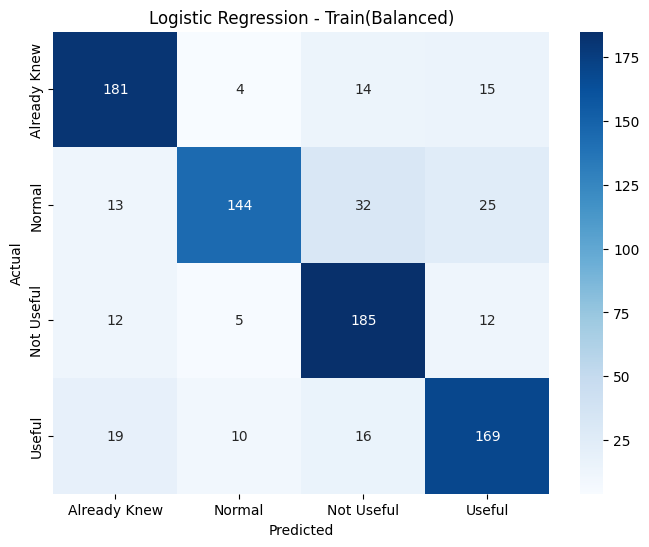

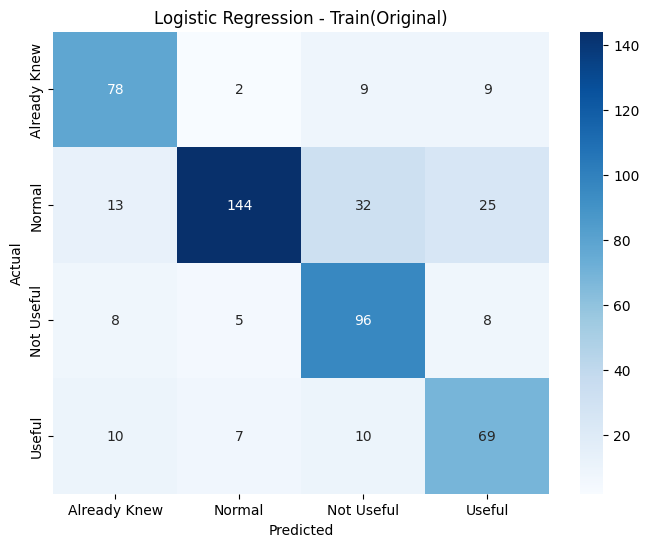

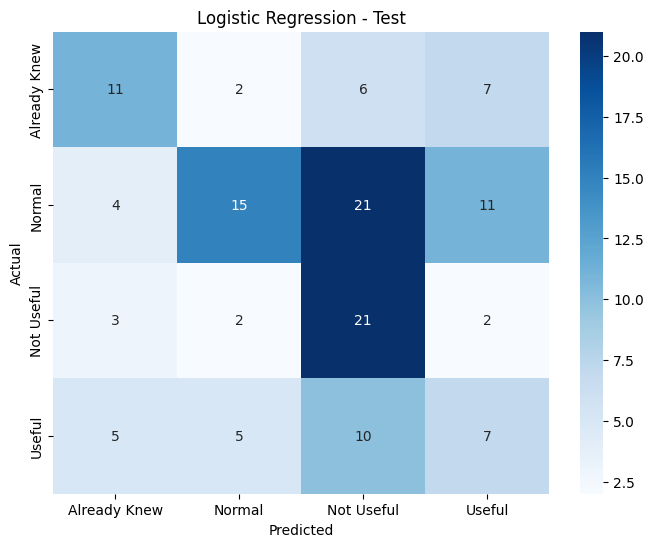

              precision    recall  f1-score   support

Already Knew       0.72      0.80      0.75        98
      Normal       0.91      0.67      0.77       214
  Not Useful       0.65      0.82      0.73       117
      Useful       0.62      0.72      0.67        96

    accuracy                           0.74       525
   macro avg       0.73      0.75      0.73       525
weighted avg       0.76      0.74      0.74       525

              precision    recall  f1-score   support

Already Knew       0.48      0.42      0.45        26
      Normal       0.62      0.29      0.40        51
  Not Useful       0.36      0.75      0.49        28
      Useful       0.26      0.26      0.26        27

    accuracy                           0.41       132
   macro avg       0.43      0.43      0.40       132
weighted avg       0.47      0.41      0.40       132



In [6]:
##################### Train LogisticRegression
lr_model = LogisticRegression(
    random_state=RANDOM_STATE
    ,C = 0.01
    ,penalty ="l2"
    # ,solver="liblinear"
    )
lr_model.fit(X_train_balanced_chosen, y_train_balanced_chosen)



# from sklearn.model_selection import GridSearchCV

# param_grid = {
#     "C": [10, 1, 0.1, 0.01],
#     "penalty": ["l1", "l2"],
#     "solver": ["liblinear","saga"],
#     "max_iter": [1000],
# }

# grid = GridSearchCV(
#     LogisticRegression(random_state=RANDOM_STATE),
#     param_grid,
#     cv=5,
#     scoring="accuracy",
#     n_jobs=-1
# )

# grid.fit(X_train_balanced_chosen, y_train_balanced_chosen)
# print(grid.best_params_, grid.best_score_)


# pred_train_lr = nlp_predict(data_train,lr_model,vectorizer_chosen, col_input= X_COL_NAME,inplace=False)
# pred_test_lr = nlp_predict(data_test,lr_model,vectorizer_chosen, col_input= X_COL_NAME, inplace=False)

pred_train_balance_lr = lr_model.predict(X_train_balanced_chosen)
pred_train_imbalance_lr = lr_model.predict(X_train_imbalanced_chosen)
pred_test_lr = lr_model.predict(X_test_chosen)


# pred_train_lr_prob = nlp_predict_prob(data_train,lr_model,vectorizer_chosen, col_input= X_COL_NAME,inplace=True)
# pred_test_lr_prob = nlp_predict_prob(data_test,lr_model,vectorizer_chosen, col_input= X_COL_NAME, inplace=False)
pred_train_lr_prob = lr_model.predict_proba(X_train_balanced_chosen)
pred_test_lr_prob = lr_model.predict_proba(X_test_chosen)

# tfidf_vectorizer = vectorizer_chosen
# data_in = data_train[X_COL_NAME]
model = lr_model

# data_tfidf = tfidf_vectorizer.transform(data_in)
# prediction = model.predict_proba(data_tfidf)
labels = model.classes_.tolist()

# labels = ['Not Useful','Already Knew','Normal','Useful']

# cm = confusion_matrix(pred_train_lr[y_name], pred_train_lr['prediction'])
# cm

plot_confusion_matrix(y_train_balanced_chosen, pred_train_balance_lr, 'Logistic Regression - Train(Balanced)',labels)
plot_confusion_matrix(y_train_imbalanced_chosen, pred_train_imbalance_lr, 'Logistic Regression - Train(Original)',labels)
plot_confusion_matrix(y_test, pred_test_lr, 'Logistic Regression - Test',labels)


cr_lr_train = classification_report(y_train_imbalanced_chosen, pred_train_imbalance_lr)
print(cr_lr_train)

cr_lr_test = classification_report(y_test, pred_test_lr)
print(cr_lr_test)


[50]	valid_0's multi_logloss: 1.35544
[100]	valid_0's multi_logloss: 1.35568


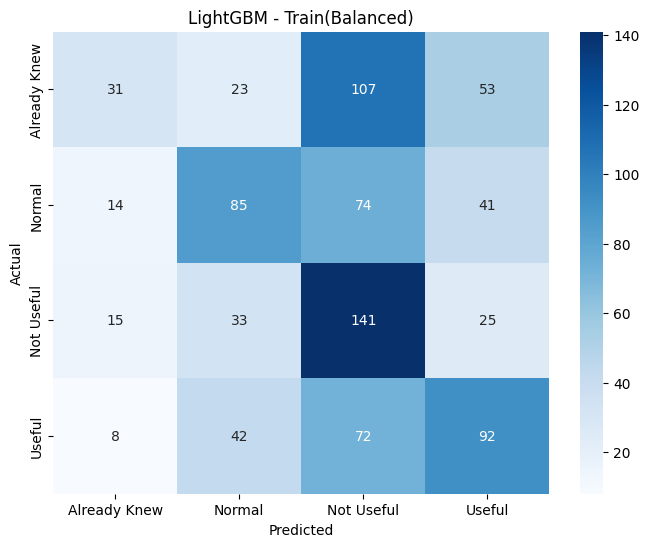

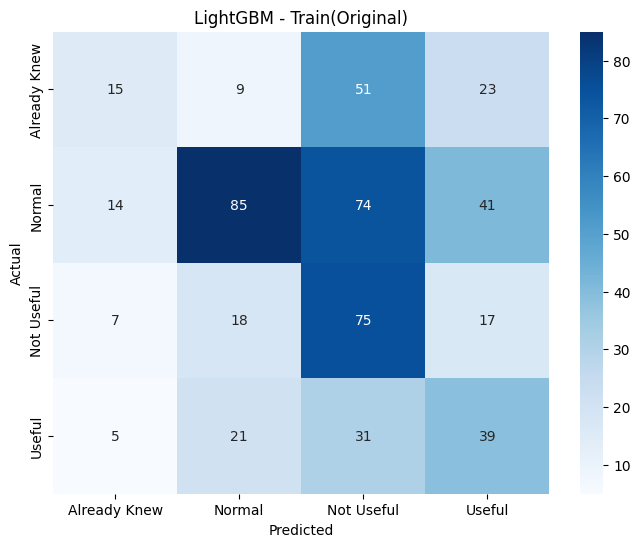

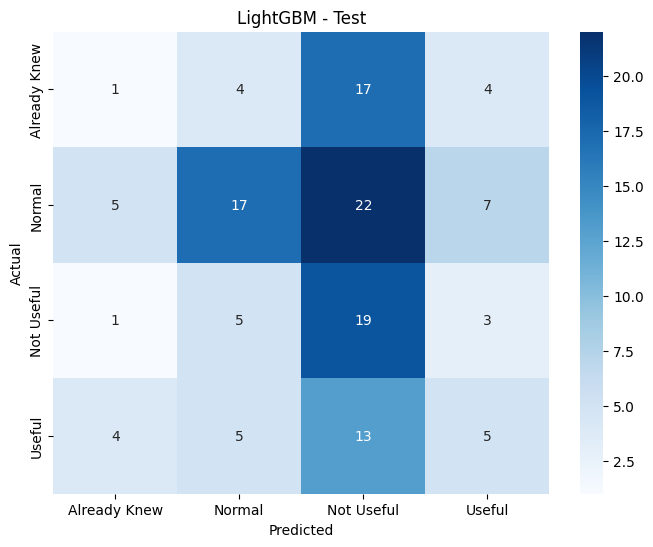

              precision    recall  f1-score   support

Already Knew       0.46      0.14      0.22       214
      Normal       0.46      0.40      0.43       214
  Not Useful       0.36      0.66      0.46       214
      Useful       0.44      0.43      0.43       214

    accuracy                           0.41       856
   macro avg       0.43      0.41      0.39       856
weighted avg       0.43      0.41      0.39       856

              precision    recall  f1-score   support

Already Knew       0.09      0.04      0.05        26
      Normal       0.55      0.33      0.41        51
  Not Useful       0.27      0.68      0.38        28
      Useful       0.26      0.19      0.22        27

    accuracy                           0.32       132
   macro avg       0.29      0.31      0.27       132
weighted avg       0.34      0.32      0.30       132



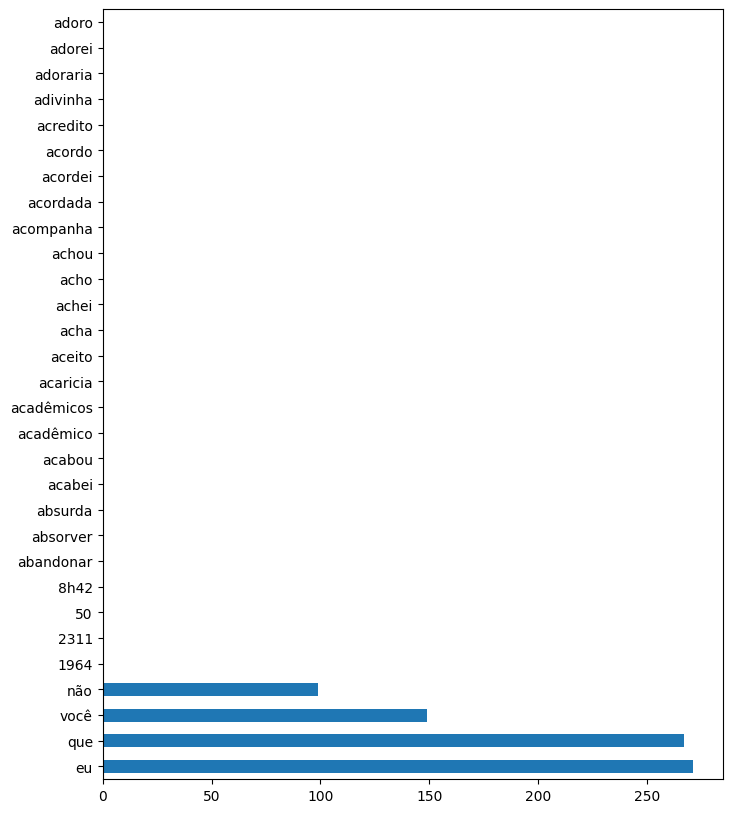

In [7]:
############################### Train lightgbm

lgb_train_balanced_data = lgb.Dataset(data=X_train_balanced_chosen, label=y_train_balanced_chosen)
lgb_test_data = lgb.Dataset(data=X_test_chosen, label=y_test)

params01 = {
    # 'objective': 'multiclass',
    # 'metric': 'multi_logloss',
    # auto numclass
    # 'num_class': 2,
    'max_depth':30,
    'num_leaves': 30,
    'max_bin': 260,
    
    'feature_fraction': 0.9,
    'bagging_fraction': 0.8,
    
    
    'boosting_type': 'gbdt',
    'learning_rate': 0.05,
    'bagging_freq': 5,
    'verbosity': -1,

    
    "min_data_in_leaf":100
}


lgb_model = lgb.LGBMClassifier(**params01)

callbacks = [lgb.log_evaluation(period=50)]


lgb_model.fit(X_train_balanced_chosen, y_train_balanced_chosen, eval_set=(X_test_chosen, y_test),callbacks=callbacks)


# cv_results = lgb.cv(params01, lgb_train_balanced_data,nfold=CV, stratified=True)

y_pred_balanced_train_lgb = lgb_model.predict(X_train_balanced_chosen)
y_pred_imbalanced_train_lgb = lgb_model.predict(X_train_imbalanced_chosen)
y_pred_test_lgb = lgb_model.predict(X_test_chosen)


plot_confusion_matrix(y_train_balanced_chosen, y_pred_balanced_train_lgb, 'LightGBM - Train(Balanced)',labels)
plot_confusion_matrix(y_train_imbalanced_chosen, y_pred_imbalanced_train_lgb, 'LightGBM - Train(Original)',labels)
plot_confusion_matrix(y_test, y_pred_test_lgb, 'LightGBM - Test',labels)


print(classification_report(y_train_balanced_chosen, y_pred_balanced_train_lgb))
# print(confusion_matrix(y_train_balanced_chosen, y_pred_balanced_train))

feat_imp = pd.Series(lgb_model.feature_importances_, index=X_train_balanced_chosen.columns)
feat_imp.nlargest(30).plot(kind='barh', figsize=(8,10))


print(classification_report(y_test, y_pred_test_lgb))
# print(confusion_matrix(y_test, y_pred_test))
